# Violent Crime Capstone

This notebook:
- Adds square footage information from the census bureau
- Calculates and visualizes population density
- save as "capstone_count_rate_density.csv"

# 1. Import data and add Square footage information

In [16]:
import pandas as pd

df = pd.read_csv("capstone_data_with_crime_rate.csv")
df.head()

,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,...,population,violent_crime_rate_per_100k,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate,county_state,poverty_bin,unemployment_bin,education_bin
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,...,59947,90.079570,1.668140,11.676981,0.000000,76.734449,"Autauga, ALABAMA",Medium-Low,Low,Medium-High
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,...,246989,55.468057,0.000000,1.619505,0.000000,53.848552,"Baldwin, ALABAMA",Low,Low,High
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,...,22130,153.637596,0.000000,22.593764,0.000000,131.043832,"Bibb, ALABAMA",High,Low,Low
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,...,59518,137.773447,1.680164,30.242952,3.360328,102.490003,"Blount, ALABAMA",Medium-Low,Low,Low
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,...,116090,205.013352,1.722801,4.307003,0.000000,198.983547,"Calhoun, ALABAMA",High,Low,Medium-Low


In [17]:
import geopandas as gpd

gdf = gpd.read_file("tl_2024_us_county/tl_2024_us_county.shp")
gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477563042,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55525 41.82892, -96.55524 41.827..."
1,53,069,01513275,53069,0500000US53069,Wahkiakum,Wahkiakum County,06,H1,G4020,NaN,NaN,NaN,A,680980773,61564428,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,00933054,35011,0500000US35011,De Baca,De Baca County,06,H1,G4020,NaN,NaN,NaN,A,6016818941,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169269508,22850511,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645201,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


In [18]:
gdf = gdf[["GEOID", "ALAND"]].copy()

In [19]:
df["fips"] = df["fips"].astype(str).str.zfill(5)
gdf["GEOID"] = gdf["GEOID"].astype(str)

In [20]:
df = df.merge(gdf, left_on="fips", right_on="GEOID", how="left")

In [21]:
df["ALAND"].isna().sum()

np.int64(0)

In [22]:
df[["fips", "ALAND"]].head()

,fips,ALAND
0,01001,1539631459
1,01003,4117781416
2,01007,1612188713
3,01009,1670259099
4,01015,1569256885


## 2. Calculate Population Density

In [23]:
df["land_area_sq_miles"] = df["ALAND"] / 2_589_988
df["population_density"] = df["population"] / df["land_area_sq_miles"]

In [24]:
df["population_density"].describe()

count    1858.000000
mean      192.263619
std       438.803060
min         1.793317
25%        31.425146
50%        64.078213
75%       154.441446
max      6844.739101
Name: population_density, dtype: float64

In [25]:
df.sort_values("population_density", ascending=False)[
    ["county", "state", "population_density"]
].head(10)

,county,state,population_density
1017,Essex,NEW JERSEY,6844.739101
355,Cook,ILLINOIS,5484.136244
1044,Nassau,NEW YORK,4883.572361
133,Orange,CALIFORNIA,3992.876669
1797,Milwaukee,WISCONSIN,3836.414530
814,Ramsey,MINNESOTA,3565.973472
220,Pinellas,FLORIDA,3519.068593
1489,Dallas,TEXAS,3001.947294
759,Wayne,MICHIGAN,2896.606246
254,DeKalb,GEORGIA,2859.351167


In [26]:
df.sort_values("population_density", ascending=True)[
    ["county", "state", "population_density"]
].head(10)

,county,state,population_density
1008,Humboldt,NEVADA,1.793317
161,Inyo,CALIFORNIA,1.837650
1634,Millard,UTAH,1.962278
343,Idaho,IDAHO,2.056267
1632,Emery,UTAH,2.251136
1034,Socorro,NEW MEXICO,2.437415
967,Big Horn,MONTANA,2.579346
969,Fergus,MONTANA,2.693273
1009,Nye,NEVADA,2.988904
191,Las Animas,COLORADO,3.019733


## 3. Visulizes Population Denstiy vs. Crime

In [27]:
df.dtypes

state                                             str
metropolitan_nonmetropolitan                      str
county                                            str
violent_crime_count                             int64
murder_and_nonnegligent_manslaughter_count      int64
rape_count                                      int64
robbery_count                                   int64
aggravated_assault_count                        int64
property_crime                                  int64
burglary                                        int64
larceny_theft                                   int64
motor_vehicle_theft                             int64
arson                                           int64
year                                            int64
state.1                                           str
county_clean                                      str
fips                                              str
county.1                                          str
labor_force                 

In [28]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent Manslaughter) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State",
    "county_state": "County State",
    "population_density": "Population Density"
}

In [29]:
df[["population_density", "violent_crime_rate_per_100k"]].corr()

,population_density,violent_crime_rate_per_100k
population_density,1.000000,-0.142959
violent_crime_rate_per_100k,-0.142959,1.000000


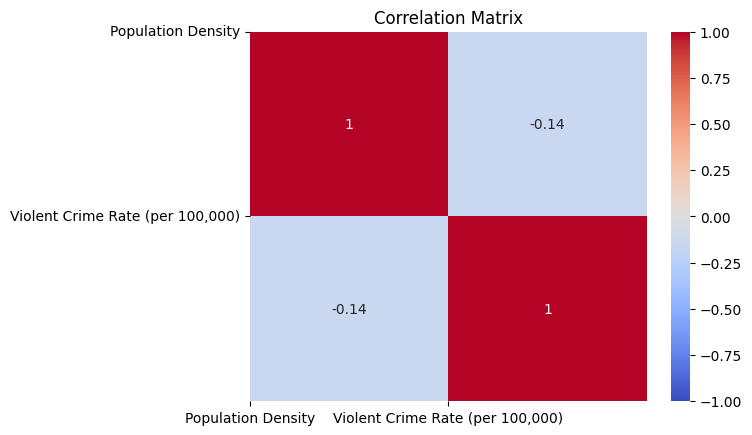

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["population_density", "violent_crime_rate_per_100k"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

labels = ["Population Density", "Violent Crime Rate (per 100,000)"]

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha="center")
plt.yticks(ticks=range(len(labels)), labels=labels, rotation=0, va="center")

plt.title("Correlation Matrix")

plt.show()

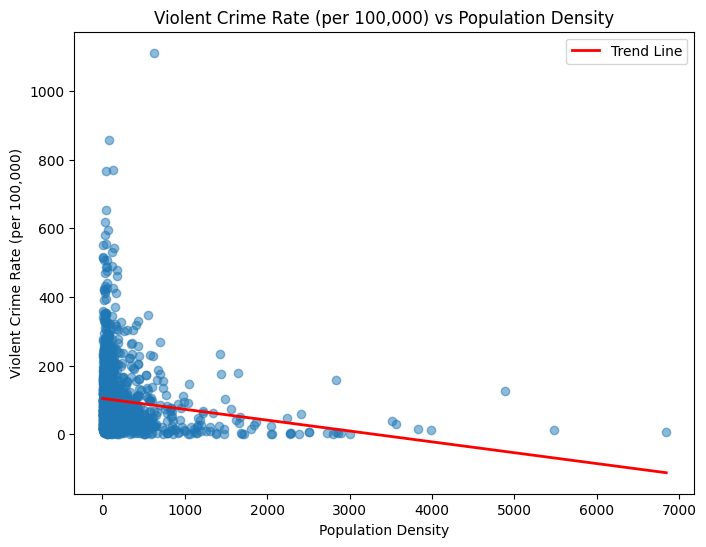

In [32]:
import matplotlib.pyplot as plt
import numpy as np

x = "population_density"
y = "violent_crime_rate_per_100k"

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df[x], df[y], alpha=0.5)

# Trend
z = np.polyfit(df[x], df[y], 1)
p = np.poly1d(z)

x_vals = np.linspace(df[x].min(), df[x].max(), 100)
plt.plot(x_vals, p(x_vals), color="red", linewidth=2, label="Trend Line")
plt.legend()

# Labels
plt.xlabel(label_map.get(x, x))
plt.ylabel(label_map.get(y, y))
plt.title(f"{label_map.get(y, y)} vs {label_map.get(x, x)}")

plt.show()

In [33]:
df.to_csv("capstone_count_rate_density.csv", index=False)